# Python pour la Data Science

## Notebook 04 - Data visualisation avec Matplotlib

### Prérequis
Dans les notebooks précédents, nous avons déjà manipulé :

- les structures de données Python ;
- les tableaux NumPy ;
- les DataFrames Pandas.

Ici, nous allons ajouter une nouvelle compétence essentielle : **représenter visuellement les données** avec Matplotlib

Nous pouvons pour cela nous appuyer sur le tutoriel suivant : https://www.geeksforgeeks.org/python/python-introduction-matplotlib/

### Objectifs de la séance
À la fin de ce notebook, vous serez capables de :

- importer et utiliser Matplotlib ;
- choisir un graphique adapté à une question simple ;
- personnaliser un graphique (titre, axes, couleurs, taille, grille) ;
- produire plusieurs graphiques à partir d'un même dataset ;
- sauvegarder une figure dans un fichier avec `savefig`.

### Fil conducteur
Nous allons travailler à partir du dataset **Titanic**. L'idée n'est pas seulement de “faire des graphiques”, mais de **mieux comprendre les données** grâce à eux.

### Organisation du notebook
1. Initialisation
2. Chargement et exploration rapide du dataset Titanic
3. Premier graphique : l'histogramme
4. Comparer des catégories avec un diagramme en barres
5. Relier deux variables avec un nuage de points
6. Comparer des distributions avec un boxplot
7. Composer plusieurs graphiques avec des sous-figures
8. Bonus : sauvegarder une figure avec `savefig`

## 1. Initialisation

Comme d'habitude, on commence par importer les bibliothèques dont on aura besoin.

- **NumPy** peut être utile pour préparer certaines données ;
- **Pandas** sert à charger et manipuler le dataset ;
- **Matplotlib** sert à créer les graphiques.

> Dans ce notebook, nous utiliserons surtout `matplotlib.pyplot`, souvent abrégé en `plt`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Chargement du dataset de travail

Nous allons maintenant charger le fichier `Titanic-Dataset.csv`.

Avant de visualiser quoi que ce soit, il faut toujours prendre quelques minutes pour :

- regarder les premières lignes ;
- identifier les colonnes disponibles ;
- repérer les valeurs manquantes ;
- vérifier le type des variables.

C'est une étape importante : **un bon graphique commence par une bonne compréhension du dataset**.


In [2]:
df = pd.read_csv("../datasets/Titanic-Dataset.csv")

print("Dimensions du dataset :", df.shape)
df.head(10)

Dimensions du dataset : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Observer la structure des données

Les instructions ci-dessous permettent de résumer rapidement le dataset :

- `info()` donne les types et le nombre de valeurs non nulles ;
- `describe()` résume les colonnes numériques.

**Consigne :** repérez en particulier si certaines colonnes contiennent des valeurs manquantes. Cela aura un impact sur certains graphiques.


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Repérer les colonnes utiles pour la visualisation

Sur Titanic, quelques colonnes sont particulièrement intéressantes :

- `Survived` : le passager a-t-il survécu ?
- `Pclass` : classe du billet (1, 2 ou 3)
- `Sex` : sexe du passager
- `Age` : âge
- `Fare` : prix du billet
- `Embarked` : port d'embarquement

Nous allons construire nos graphiques progressivement, du plus simple au plus riche.


# 3. Premier type de graphique : l'histogramme

Un **histogramme** permet de visualiser la **distribution** d'une variable numérique.

Ici, nous allons regarder la répartition des âges des passagers.

### Point d'attention
La colonne `Age` contient souvent des valeurs manquantes dans le dataset Titanic. Pour éviter les problèmes, on peut utiliser `dropna()`. Pourquoi ne pas utiliser `df["Age"].fillna(df["Age"].mean())` comme on l'a fait pécédemment ?

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

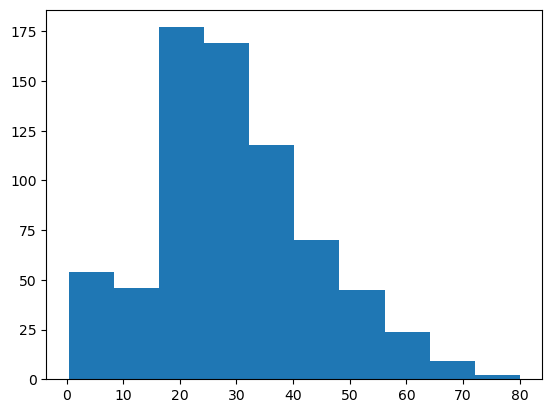

In [4]:
plt.hist(df["Age"].dropna())

Par défaut, `plt.hist` affichera 10 éléments de dessin, ici 10 barres verticales (ces objets graphiques sont les "artists" mentionnés dans la cellule précédente). On peut modifier le nombre d'éléments pour arriver à la précision voulue (et pertinente suivant les données que l'on cherche à traiter) en ajoutant l'argument "bins" :

(array([24.,  6., 14.,  3.,  7.,  8.,  6.,  3.,  7., 22., 13., 51., 40.,
        27., 46., 24., 36., 47., 27., 35., 17., 34., 29., 11., 27.,  8.,
        18.,  9., 17., 18.,  6., 17.,  6.,  9.,  7.,  2.,  7.,  4.,  7.,
         4.,  3.,  1.,  0.,  2.,  3.,  0.,  1.,  0.,  0.,  1.]),
 array([ 0.42  ,  2.0116,  3.6032,  5.1948,  6.7864,  8.378 ,  9.9696,
        11.5612, 13.1528, 14.7444, 16.336 , 17.9276, 19.5192, 21.1108,
        22.7024, 24.294 , 25.8856, 27.4772, 29.0688, 30.6604, 32.252 ,
        33.8436, 35.4352, 37.0268, 38.6184, 40.21  , 41.8016, 43.3932,
        44.9848, 46.5764, 48.168 , 49.7596, 51.3512, 52.9428, 54.5344,
        56.126 , 57.7176, 59.3092, 60.9008, 62.4924, 64.084 , 65.6756,
        67.2672, 68.8588, 70.4504, 72.042 , 73.6336, 75.2252, 76.8168,
        78.4084, 80.    ]),
 <BarContainer object of 50 artists>)

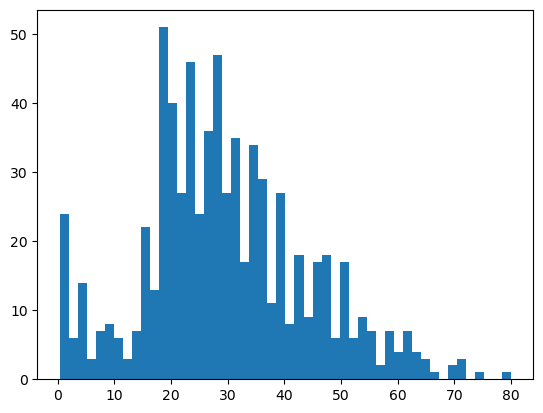

In [5]:
plt.hist(df["Age"].dropna(), bins=50)

D'autres arguments sont modifiables, notamment la couleur :

(array([24.,  6., 14.,  3.,  7.,  8.,  6.,  3.,  7., 22., 13., 51., 40.,
        27., 46., 24., 36., 47., 27., 35., 17., 34., 29., 11., 27.,  8.,
        18.,  9., 17., 18.,  6., 17.,  6.,  9.,  7.,  2.,  7.,  4.,  7.,
         4.,  3.,  1.,  0.,  2.,  3.,  0.,  1.,  0.,  0.,  1.]),
 array([ 0.42  ,  2.0116,  3.6032,  5.1948,  6.7864,  8.378 ,  9.9696,
        11.5612, 13.1528, 14.7444, 16.336 , 17.9276, 19.5192, 21.1108,
        22.7024, 24.294 , 25.8856, 27.4772, 29.0688, 30.6604, 32.252 ,
        33.8436, 35.4352, 37.0268, 38.6184, 40.21  , 41.8016, 43.3932,
        44.9848, 46.5764, 48.168 , 49.7596, 51.3512, 52.9428, 54.5344,
        56.126 , 57.7176, 59.3092, 60.9008, 62.4924, 64.084 , 65.6756,
        67.2672, 68.8588, 70.4504, 72.042 , 73.6336, 75.2252, 76.8168,
        78.4084, 80.    ]),
 <BarContainer object of 50 artists>)

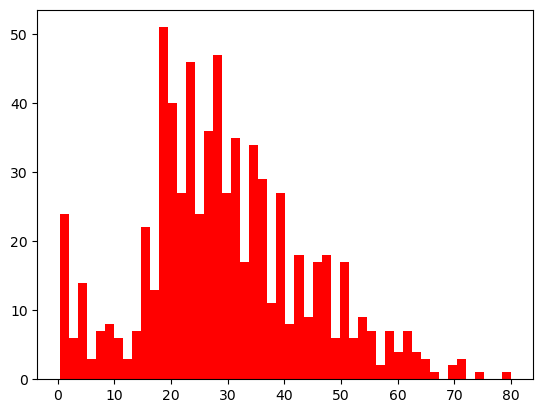

In [6]:
plt.hist(df["Age"].dropna(), bins=50, color='r')

En général, on évitera d'afficher autre chose que le graphique en utilisant `plt.show()` après nos commandes de dessin :

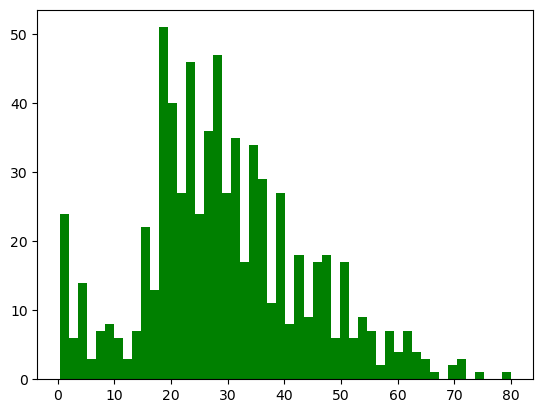

In [7]:
plt.hist(df["Age"].dropna(), bins=50, color='g')
plt.show()

Commentez le graphique obtenu : est-ce qu'il vous semble bon pour l'analyse de données ?

### Obtenir des graphiques convenables

En général, pour communiquer autour des données que l'on traite, on essaye de mettre un titre aux graphes que l'on dessine, ainsi qu'à ses axes. Matplotlib permet de faire cela très facilement :

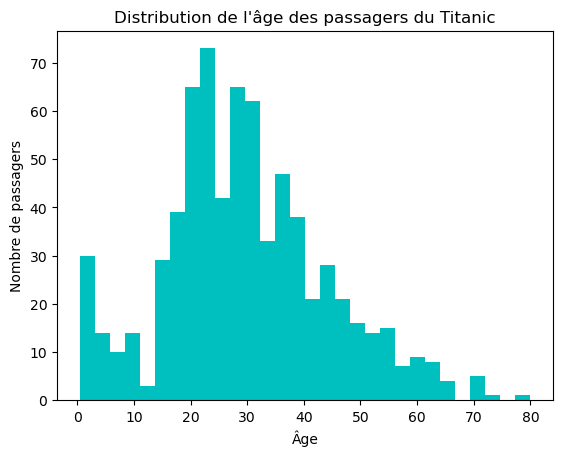

In [8]:
plt.hist(df["Age"].dropna(), bins=30, color='c')
plt.title("Distribution de l'âge des passagers du Titanic")
plt.xlabel("Âge")
plt.ylabel("Nombre de passagers")
plt.show()

### Ajustements des graphes

On peut encore améliorer le rendu des graphes en configurant la taille de la fenêtre utilisée avec `plt.figsize`, voire en ajoutant une grille (ou cadrillage) avec `plt.grid` :

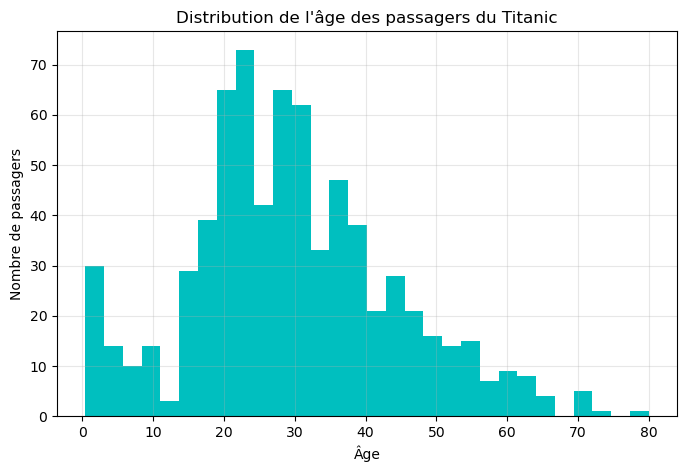

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"].dropna(), bins=30, color='c')
plt.title("Distribution de l'âge des passagers du Titanic")
plt.xlabel("Âge")
plt.ylabel("Nombre de passagers")

plt.grid(True, alpha=0.3)

plt.show()

### Résumé : les fonctions principales de Matplotlib

Avec Matplotlib, on peut facilement générer un graphe et en améliorer la lisibilité en manipulant les **fonctions** associées à cette bibliothèque :

- `figure` où l'on précisera en argument la taille souhaitée pour le graphe, c'est souvent par là qu'on commence
- on crée ensuite le graphe qu'on souhaite, ici un histogramme avec `hist`
- on rajoute une grille avec `grid` (dont on peut préciser la transparence avec l'argument `alpha`)
- puis on affiche le graphe avec `show`

# 4. Comparer des catégories : le diagramme en barres

Quand on veut comparer des **effectifs** ou des **fréquences** entre plusieurs catégories, le **diagramme en barres** est souvent un très bon choix.

C'est comme un histogramme, mais dont on va devoir préciser les axes.

Commençons par observer le nombre de passagers dans chaque classe (`Pclass`) : 

- On crée une Series qui contient le nombre d'occurrences de chaque valeur de Pclass
- On utilise `plt.bar` en lui disant en argument ce que doivent être les axes de abscisses et des ordonnées : l'index de la Series (les différentes valeurs que Pclass peut prendre) en abscisses, les valeurs associées en ordonnées :

Que remarque-t-on ?

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<BarContainer object of 3 artists>

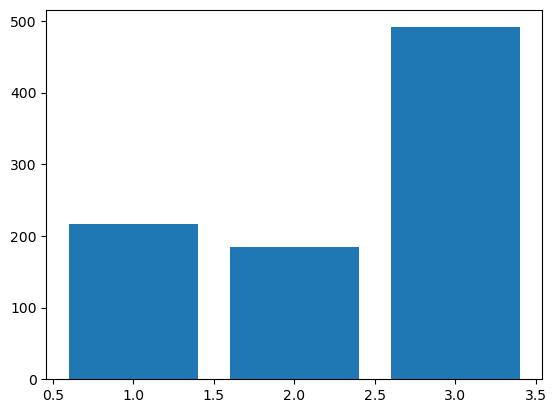

In [10]:
pclass_counts = df["Pclass"].value_counts()

display(pclass_counts.head())

plt.bar(pclass_counts.index, pclass_counts.values)

La fonction `bar` comprend que les index de la Series sont des nombres, on peut modifier ça en convertissant en chaîne de caractères :

<BarContainer object of 3 artists>

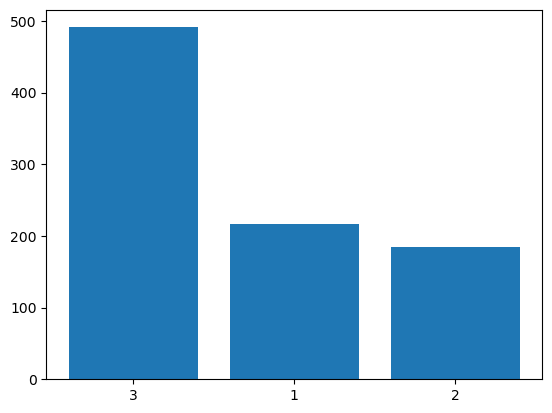

In [11]:
plt.bar(pclass_counts.index.astype(str), pclass_counts.values)

On a presque un début de graphe convaincant, qu'on peut encore améliorer en observant que c'est dans la Series extraite du DataFrame que les index sont organisés de celui qui a le plus grand nombre d'occurences puis en décroissant : **dans une data visualisation, on veut que ça soit parlant pour le plus grand nombre de lecteurs**

On va rendre ça plus intuitif en réorganisant le DataFrame :

<BarContainer object of 3 artists>

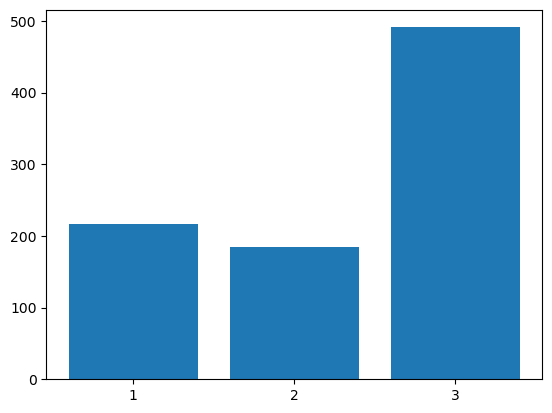

In [12]:
pclass_counts = df["Pclass"].value_counts().sort_index()

plt.bar(pclass_counts.index.astype(str), pclass_counts.values)

### Exercice 1 - Amélioration du graphe

Comment rendre meilleur ce graphe et obtenir un graphe propre ?

###  Exercice 2 - comparer les survivants par sexe

Affichez un graphe propre qui donne à voir la proportion de survivants par sexe :

# 5. Relier deux variables numériques : le nuage de points

Le **nuage de points** (scatter plot) est utile pour voir s'il existe une relation entre deux variables numériques

Nous allons comparer :

- l'**âge** (`Age`) ;
- le **prix du billet** (`Fare`)

Faire de telles choses s'associe souvent avec le fait de formuler ou de tester une hypothèse comme :

> Les passagers les plus âgés paient-ils forcément plus cher ?

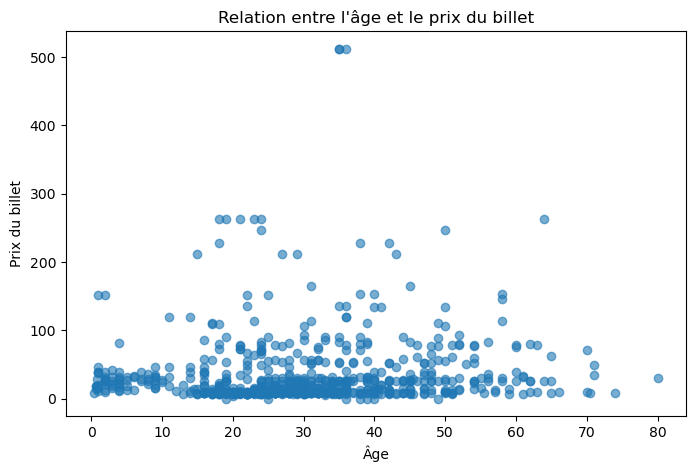

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Age"], df["Fare"], alpha=0.6)

plt.title("Relation entre l'âge et le prix du billet")
plt.xlabel("Âge")
plt.ylabel("Prix du billet")

plt.show()

### Critique du graphe

Qu'a-t-on fait lorsqu'on a fait ce graphe ? On a pris les données d'origine, sans savoir si elles étaient de qualité ou non ! Notamment, on sait que certaines valeurs d'âge sont inconnues.

Pour plus de propreté dans les graphes, on peut aussi donner en argument à la fonction `scatter` des Series que l'on extrait d'un DataFrame intermédiaire, où l'on isole les variables qui nous intéressent et que l'on nettoie :

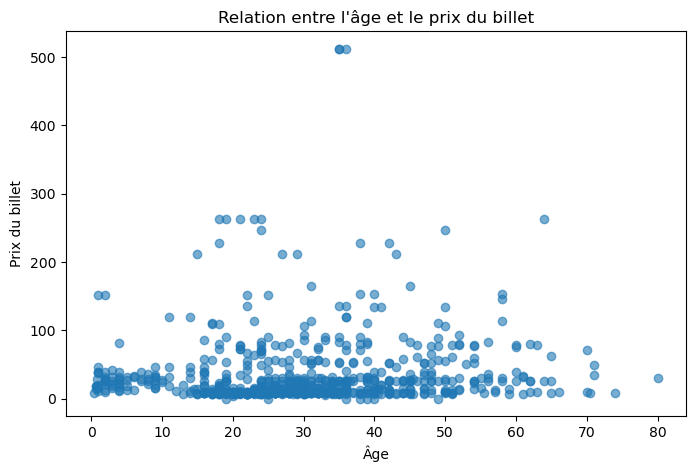

In [14]:
subset = df[["Age", "Fare"]].dropna()

plt.figure(figsize=(8, 5))

plt.scatter(subset["Age"], subset["Fare"], alpha=0.6)

plt.title("Relation entre l'âge et le prix du billet")
plt.xlabel("Âge")
plt.ylabel("Prix du billet")

plt.show()

### Interpréter un scatter plot

Sur ce type de graphique, on cherche surtout à repérer :

- une tendance générale ;
- des regroupements ;
- des valeurs atypiques (très éloignées du reste).

Que peut-on dire ici ?

# 6. Comparer des distributions : le boxplot

Le **boxplot** (ou boîte à moustaches) permet de comparer rapidement la distribution d'une variable numérique selon plusieurs groupes.

Ici, on va comparer l'âge des passagers selon la classe (`Pclass`).

C'est un graphique très utile pour repérer :

- la médiane ;
- la dispersion ;
- les valeurs extrêmes.


`boxplot` compare des Series, donc il faut commencer par isoler les Series correspondent à Pclass = 1, 2, etc. Et on doit aussi mettre en qualité les données, donc pour le moment enlever les valeurs manquantes :

In [15]:
age_by_class = [
    df.loc[df["Pclass"] == 1, "Age"].dropna(),
    df.loc[df["Pclass"] == 2, "Age"].dropna(),
    df.loc[df["Pclass"] == 3, "Age"].dropna(),
]

print(type(age_by_class))
print(type(age_by_class[1]))

<class 'list'>
<class 'pandas.core.series.Series'>


On obtient une liste faite de trois Series, que l'on va donner en argument à la fonction `boxplot` :

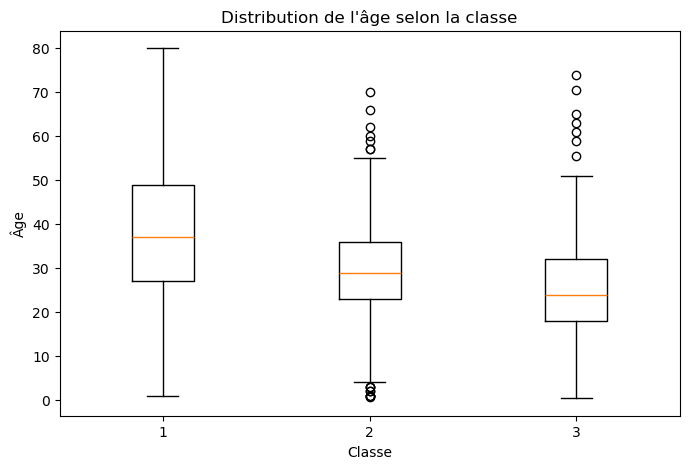

In [16]:
plt.figure(figsize=(8, 5))

plt.boxplot(age_by_class)

plt.title("Distribution de l'âge selon la classe")
plt.xlabel("Classe")
plt.ylabel("Âge")

plt.show()

Si on se renseigne sur le fonctionnement de la fonction `boxplot`, on voit qu'on peut se passer de nommer l'axe des abscisses en complétant l'argument `tick_labels` qui donne une série de chaînes de caractères pour dire ce à quoi correspond chaque Series :

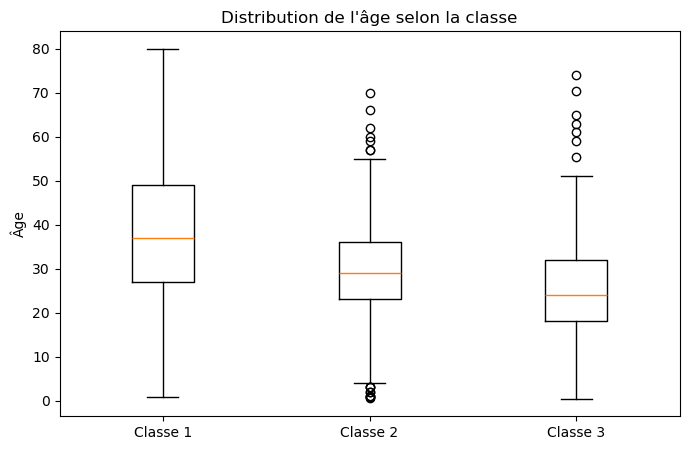

In [17]:
plt.figure(figsize=(8, 5))

plt.boxplot(age_by_class, tick_labels=["Classe 1", "Classe 2", "Classe 3"])

plt.title("Distribution de l'âge selon la classe")
plt.ylabel("Âge")

plt.show()

### Lecture d’un boxplot :

- La boîte contient les 50% centraux des données (entre Q1 et Q3)
- La ligne au milieu correspond à la médiane
- Les moustaches montrent l’étendue des valeurs “normales”
- Les points représentent les valeurs extrêmes (outliers)

**Plus la boîte est grande, plus les données sont dispersées**

### Question d'analyse

À partir du boxplot, essayez de répondre à la question suivante :

> Les passagers des différentes classes ont-ils des profils d'âge comparables ?

# 7. Combiner plusieurs graphiques : les sous-figures

Dans une véritable analyse, on a souvent besoin de présenter plusieurs graphiques ensemble.

Matplotlib permet de construire une même figure avec plusieurs zones d'affichage grâce à `subplots`.

Dans l'exemple ci-dessous, on place côte à côte :

- un histogramme des âges ;
- un diagramme en barres du nombre de passagers par classe

Cela fonctionne quasiment à l'identique que quand on fait des figures "simples", mais ici on va déclarer deux objets : la figure principale (fig) et ses différentes zones de dessin (ax), que l'on va organiser comme on veut, ici l'un à côté de l'autre

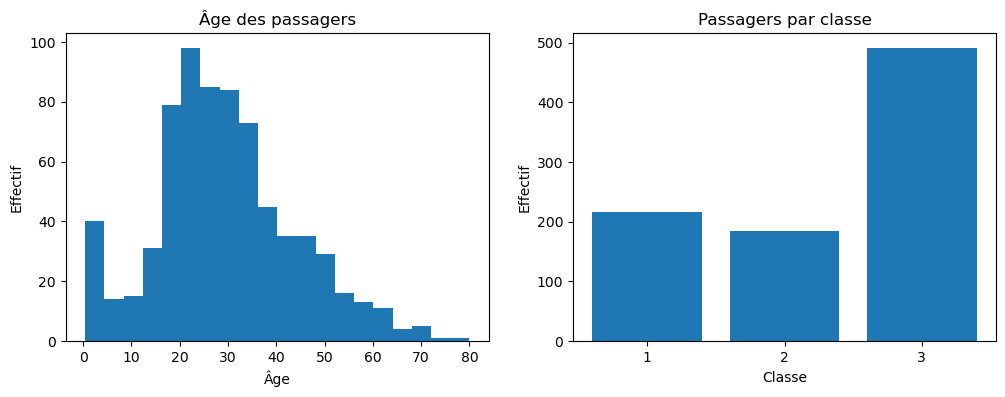

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["Age"].dropna(), bins=20)
ax[0].set_title("Âge des passagers")
ax[0].set_xlabel("Âge")
ax[0].set_ylabel("Effectif")

ax[1].bar(pclass_counts.index.astype(str), pclass_counts.values)
ax[1].set_title("Passagers par classe")
ax[1].set_xlabel("Classe")
ax[1].set_ylabel("Effectif")

plt.show()

### Pourquoi utiliser `subplots` ?

Cette approche est très utile pour :

- comparer visuellement plusieurs résultats ;
- produire une figure plus compacte pour un rapport ;
- organiser une mini-analyse de manière propre.

### Exercice

Créer ensuite une figure à deux graphiques l'un au-dessus de l'autre avec :

1. le taux de survie selon le sexe ;
2. le nuage de points entre `Age` et `Fare`.

# 8. Comparaisons croisées

On peut aussi afficher dans une même zone de graphe deux distributions pour les comparer. Cela se fait tout simplement en créant deux graphe dans la même zone :

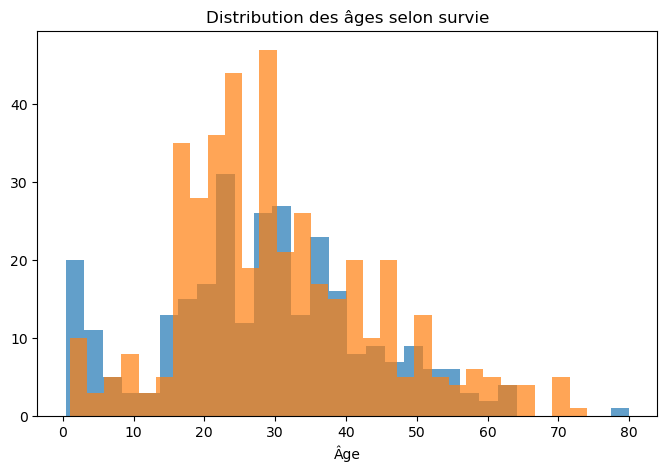

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, alpha=0.7)
plt.hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha=0.7)

plt.title("Distribution des âges selon survie")
plt.xlabel("Âge")

plt.show()

Que remarque-t-on ?

On ne sait pas quoi correspond à quoi, le graphe est illisible ! Lorsqu'on crée deux graphes dans la même zone, il faut préciser la légende en appelant la fonction `legend` après avoir précisé en argument des graphes à quoi ils correspondent avec `label` :

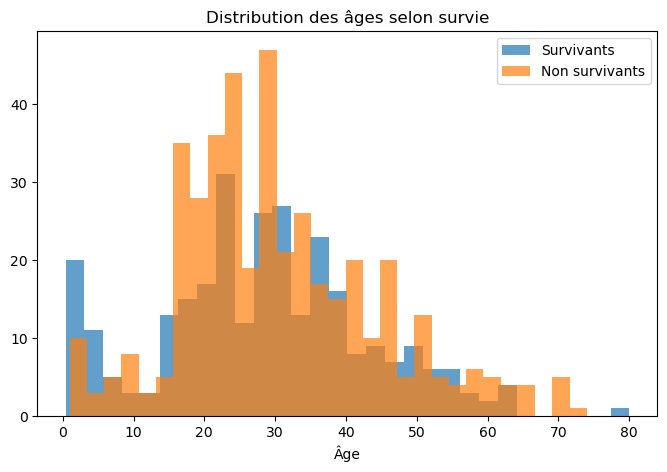

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, alpha=0.7, label="Survivants")
plt.hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha=0.7, label="Non survivants")

plt.legend()
plt.title("Distribution des âges selon survie")
plt.xlabel("Âge")

plt.show()

### Exercice

Créer un graphique montrant la relation entre :
- Age (x)
- Fare (y)

Mais en distinguant :
- les survivants
- les non-survivants

Interprétation ?

Pandas combiné avec Matplotlib permet de faire des comparaisons croisées rapidement, par exemple, que s'affiche-t-il si j'exécute la cellule suivante :

# 9. Sauvegarder une figure avec `savefig`

Lorsque vous préparez un compte rendu, un support de cours ou un rapport, il est souvent utile d'enregistrer une figure dans un fichier image.

La méthode `savefig` permet de sauvegarder le graphique produit par Matplotlib.

### Important
En général, on appelle `savefig(...)` **avant** `show()`

Dans l'exemple suivant, on sauvegarde un histogramme des âges au format PNG

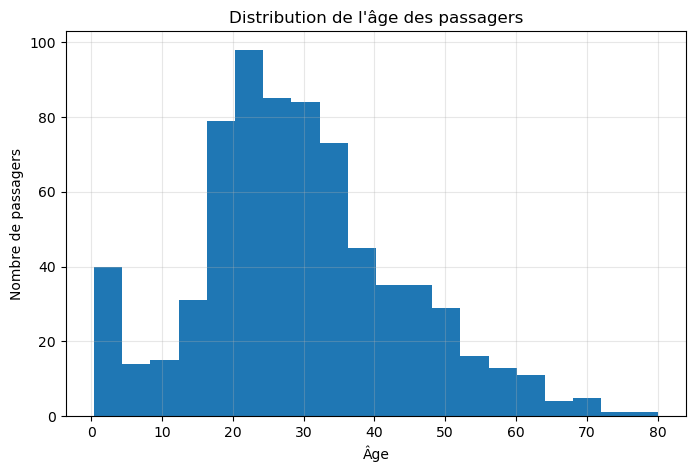

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df["Age"].dropna(), bins=20)
plt.title("Distribution de l'âge des passagers")
plt.xlabel("Âge")
plt.ylabel("Nombre de passagers")
plt.grid(True, alpha=0.3)

plt.savefig("histogramme_age_titanic.png", dpi=300, bbox_inches="tight")
plt.show()

## Ce qu'il faut retenir

Dans ce notebook, vous avez appris à :

- créer un histogramme ;
- comparer des catégories avec un diagramme en barres ;
- représenter une relation avec un nuage de points ;
- comparer des distributions avec un boxplot ;
- organiser plusieurs graphiques avec `subplots` ;
- sauvegarder une figure avec `savefig`

# Mini-projet - Analyse du dataset Iris

## Données

Chargez le dataset `Iris.csv`, puis explorez-le rapidement :

- Combien y a-t-il d’observations ?
- Combien y a-t-il de variables ?
- Quelles sont les espèces présentes ?

## Travail demandé

Vous devez produire une **analyse visuelle** permettant de répondre à la question :

*Comment distinguer les différentes espèces d’iris ?*

Réalisez **3 à 5 visualisations pertinentes**.

Vos visualisations doivent inclure :

- au moins **1 histogramme** (distribution d’une variable)
- au moins **1 comparaison entre espèces**
- au moins **1 graphique libre** (au choix)

## Pistes de réflexion

Vous pouvez vous poser les questions suivantes :

- Les pétales sont-ils plus discriminants que les sépales ?
- Une espèce est-elle clairement identifiable ?
- Certaines espèces se ressemblent-elles ?
- Quelles variables permettent le mieux de distinguer les espèces ?

## Pour chaque graphique

Vous devez fournir :

1. Le code utilisé
2. Le graphique obtenu
3. Une **interprétation (2-3 phrases)** expliquant ce que vous observez

## Bonus (optionnel)

- Représentez deux variables en même temps (scatter plot)
- Essayez de **colorier les points selon l’espèce**

---

L’objectif n’est pas seulement de faire des graphiques, mais de **raconter une histoire avec les données**